In [1]:
import pandas as pd
from pathlib import Path

In [2]:
print(Path.cwd())
df1 = pd.read_csv("../../labelling/top_boundaries_opener_labels.csv")
print(df1.shape)

/Users/anna/my_projects/NormErosionGerParl/Rhetoric-Change-in-Plenary-de/measurement/top_change
(13031, 11)


In [3]:
df2 = pd.read_csv("../../labelling/top_boundaries_annotation_input.csv")

print("Columns in df1:", list(df1.columns))
print("Columns in df2:", list(df2.columns))

new_cols_from_df1 = df1.columns.difference(df2.columns)
print("\nCols to add:", list(new_cols_from_df1))

# df1 and df2 are NOT row-aligned. The annotator app writes gold labels in
# labeling order (a dict keyed by protocol_id/start_pos), not input-file order,
# so a positional concat silently pairs ~11% of rows with the wrong label.
# Merge on the actual key instead.
key_cols = ["protocol_id", "start_pos"]
result_df = df2.merge(
    df1[key_cols + list(new_cols_from_df1)],
    on=key_cols, how="left", validate="one_to_one",
)

print("\nNew df:")
print(list(result_df.columns))
print("\nShape:")
print(result_df.shape)

# PROVISIONAL: the annotation-input file currently has more protocols (95) than
# the gold-label file (47) -- the extra ~48 are newly sampled but not yet
# labeled (still being sorted out with Anna). Filtering them out here so the
# rest of the notebook keeps running on the same 47-protocol labeled set as
# before, rather than breaking on NaN targets. Remove this filter once the
# labeling situation is resolved.
n_missing = result_df["is_opener"].isna().sum()
print(f"\nRows missing a gold label: {n_missing} (dropped -- not yet annotated)")
result_df = result_df[result_df["is_opener"].notna()].reset_index(drop=True)
print("Shape after dropping unlabeled rows:", result_df.shape)
result_df.head(20)

Columns in df1: ['protocol_id', 'state', 'date', 'url', 'start_pos', 'end_pos', 'is_opener', 'type', 'sponsor', 'topic', 'notes']
Columns in df2: ['protocol_id', 'state', 'date', 'url', 'start_pos', 'end_pos', 'content']

Cols to add: ['is_opener', 'notes', 'sponsor', 'topic', 'type']

New df:
['protocol_id', 'state', 'date', 'url', 'start_pos', 'end_pos', 'content', 'is_opener', 'notes', 'sponsor', 'topic', 'type']

Shape:
(13031, 12)

Rows missing a gold label: 0 (dropped -- not yet annotated)
Shape after dropping unlabeled rows: (13031, 12)


,protocol_id,state,date,url,start_pos,end_pos,content,is_opener,notes,sponsor,topic,type
0,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,1,1,Meine sehr geehrten Damen und Herren! Liebe Ko...,1,Fortsetzung der 2. Lesung des Gesetzes über di...,NaN,Haushalt,NaN
1,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,2,2,Gesetz über die Feststellung des Haushaltsplan...,0,Einzelpläne einzelner Ministerien. Doch alles ...,NaN,NaN,NaN
2,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,3,3,Ich rufe auf:,0,NaN,NaN,NaN,NaN
3,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,4,4,Einzelplan 08 - Ministerium für Wirtschaft,0,NaN,NaN,NaN,NaN
4,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,5,5,Beschlussempfehlung und Bericht des Ausschusse...,0,NaN,NaN,NaN,NaN
5,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,6,6,Drucksache 4/1108,0,NaN,NaN,NaN,NaN
6,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,7,7,Der Haushaltsplan des Wirtschaftsministeriums ...,0,NaN,NaN,NaN,NaN
7,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,8,8,Ich erteile das Wort an die DVU-Fraktion. Es s...,0,NaN,NaN,NaN,NaN
8,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,50,50,Wir setzen mit dem Redebeitrag der SPD-Fraktio...,0,NaN,NaN,NaN,NaN
9,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,74,74,"Vielen Dank, Herr Müller. - Wir setzen die Ber...",0,NaN,NaN,NaN,NaN


## Join consecutive `pre` paragraphs into contributions

`result_df` is one row per raw `pre` paragraph. Per `labelling/top_boundaries_annotation_conventions.md`
("Joining for final TOP-level analysis"), consecutive `pre` paragraphs within a protocol
with no gap in `start_pos` are one continuous chair utterance (a transcription-chunking
artifact) and should be joined into a single text
unit before classification.

`contribution_id` is the join key: `{protocol_id}_{start_pos}-{end_pos}`. Since a
contribution is defined as a contiguous `start_pos` run, that range alone is enough to
invert the join later; no separate membership list is needed.

In [4]:
paragraphs = result_df.sort_values(["protocol_id", "start_pos"]).reset_index(drop=True)

is_new_contribution = (
    (paragraphs["protocol_id"] != paragraphs["protocol_id"].shift())
    | (paragraphs["start_pos"] != paragraphs["start_pos"].shift() + 1)
)
paragraphs["contribution_seq"] = is_new_contribution.cumsum()

def first_nonempty(s):
    vals = [v for v in s if pd.notna(v) and str(v).strip()]
    return vals[0] if vals else pd.NA

contributions = paragraphs.groupby("contribution_seq").agg(
    protocol_id=("protocol_id", "first"),
    state=("state", "first"),
    date=("date", "first"),
    url=("url", "first"),
    start_pos=("start_pos", "min"),
    end_pos=("end_pos", "max"),
    n_paragraphs=("start_pos", "size"),
    content=("content", lambda s: "\n".join(s)),
    is_opener=("is_opener", "max"),
    type=("type", first_nonempty),
    sponsor=("sponsor", first_nonempty),
    topic=("topic", first_nonempty),
).reset_index(drop=True)

contributions["contribution_id"] = (
    contributions["protocol_id"] + "_" + contributions["start_pos"].astype(str)
    + "-" + contributions["end_pos"].astype(str)
)

print(f"{len(paragraphs)} pre paragraphs -> {len(contributions)} contributions")
print(f"Contributions spanning >1 paragraph: {(contributions['n_paragraphs'] > 1).sum()}")
contributions.head(10)

13031 pre paragraphs -> 5704 contributions
Contributions spanning >1 paragraph: 1221


,protocol_id,state,date,url,start_pos,end_pos,n_paragraphs,content,is_opener,type,sponsor,topic,contribution_id
0,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,1,8,8,Meine sehr geehrten Damen und Herren! Liebe Ko...,1,NaN,NaN,Haushalt,bb_4_14_1-8
1,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,50,50,1,Wir setzen mit dem Redebeitrag der SPD-Fraktio...,0,NaN,NaN,NaN,bb_4_14_50-50
2,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,74,74,1,"Vielen Dank, Herr Müller. - Wir setzen die Ber...",0,NaN,NaN,NaN,bb_4_14_74-74
3,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,107,107,1,"Vielen Dank, Herr Christoffers. - Wir setzen m...",0,NaN,NaN,NaN,bb_4_14_107-107
4,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,140,140,1,Wir setzen mit dem Beitrag der Landesregierung...,0,NaN,NaN,NaN,bb_4_14_140-140
5,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,149,149,1,"Herr Minister, gestatten sie eine Zwischenfrage?",0,NaN,NaN,NaN,bb_4_14_149-149
6,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,151,151,1,"Bitte, Herr Vietze.",0,NaN,NaN,NaN,bb_4_14_151-151
7,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,183,183,1,"Vielen Dank, Herr Minister. - Ich begrüße eine...",0,NaN,NaN,NaN,bb_4_14_183-183
8,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,185,185,1,"Ihr hattet gerade Gelegenheit, die Strategie d...",0,NaN,NaN,NaN,bb_4_14_185-185
9,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,218,234,17,"Meine Damen und Herren, wir kommen zur Beschlu...",0,NaN,NaN,NaN,bb_4_14_218-234


## Revert: broadcast contribution-level predictions back to paragraphs

Run a classifier on `contributions["content"]` (one prediction per contribution),
then use `revert_to_paragraphs` to attach that same prediction to every paragraph
inside the contribution's `[start_pos, end_pos]` range, so results can be compared
against `df1`'s per-paragraph gold labels or merged back into the full paragraph-level
corpus.

In [5]:
def revert_to_paragraphs(contribution_predictions, paragraph_df, pred_cols):
    """Broadcast contribution-level predictions down to individual paragraphs.

    contribution_predictions: one row per contribution, needs protocol_id/start_pos/
    end_pos plus pred_cols. paragraph_df: one row per paragraph, needs protocol_id/
    start_pos. Every paragraph inside a contribution's [start_pos, end_pos] range
    gets that contribution's prediction.
    """
    exploded = contribution_predictions[["protocol_id", "start_pos", "end_pos", *pred_cols]].copy()
    exploded["start_pos"] = exploded.apply(
        lambda r: list(range(int(r["start_pos"]), int(r["end_pos"]) + 1)), axis=1
    )
    exploded = exploded.explode("start_pos").drop(columns="end_pos")

    return paragraph_df.drop(columns=pred_cols, errors="ignore").merge(
        exploded, on=["protocol_id", "start_pos"], how="left", validate="one_to_one",
    )

# Round-trip check: reverting the contribution table's own is_opener (built as the
# max over each group) must exactly reproduce that same max on every paragraph in
# the group, i.e. every paragraph in a >1-paragraph contribution that had
# is_opener==1 should come back as 1, even paragraphs that were individually 0.
reverted = revert_to_paragraphs(contributions, paragraphs, ["is_opener"])
expected = paragraphs.groupby("contribution_seq")["is_opener"].transform("max")
mismatches = (reverted["is_opener"].values != expected.values).sum()
print(f"Round-trip mismatches: {mismatches} (expect 0)")
reverted.head(20)

Round-trip mismatches: 0 (expect 0)


,protocol_id,state,date,url,start_pos,end_pos,content,notes,sponsor,topic,type,contribution_seq,is_opener
0,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,1,1,Meine sehr geehrten Damen und Herren! Liebe Ko...,Fortsetzung der 2. Lesung des Gesetzes über di...,NaN,Haushalt,NaN,1,1
1,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,2,2,Gesetz über die Feststellung des Haushaltsplan...,Einzelpläne einzelner Ministerien. Doch alles ...,NaN,NaN,NaN,1,1
2,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,3,3,Ich rufe auf:,NaN,NaN,NaN,NaN,1,1
3,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,4,4,Einzelplan 08 - Ministerium für Wirtschaft,NaN,NaN,NaN,NaN,1,1
4,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,5,5,Beschlussempfehlung und Bericht des Ausschusse...,NaN,NaN,NaN,NaN,1,1
5,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,6,6,Drucksache 4/1108,NaN,NaN,NaN,NaN,1,1
6,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,7,7,Der Haushaltsplan des Wirtschaftsministeriums ...,NaN,NaN,NaN,NaN,1,1
7,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,8,8,Ich erteile das Wort an die DVU-Fraktion. Es s...,NaN,NaN,NaN,NaN,1,1
8,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,50,50,Wir setzen mit dem Redebeitrag der SPD-Fraktio...,NaN,NaN,NaN,NaN,2,0
9,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,74,74,"Vielen Dank, Herr Müller. - Wir setzen die Ber...",NaN,NaN,NaN,NaN,3,0




NExt up: Learn a classifier that reproduces the operationalized human coding rule on unseen parliamentary debates. 80/10/10 train validation split stratified by year and state?

Baseline 1: majority class

Baseline 2: lexical classifier. like tf-idf? svm? naive bayes? random forest? 

Baseline 3: full corpus speech content similarity? in that case, without the pre texts? only party speech. for tf-idf cos sim as well as embedding based with speech sequence? maybe there is some threshhold value?

MModel A — transition paragraph only
P_i

Model B — immediate context (if at all needed. I do not need to do everything. only something that works.)
last contribution
P_i
first contribution

Model C — larger context
previous 2–3 contributions
P_i
next 2–3 contributions

## Protocol-level test split

Only 47 labeled protocols (2-3 per state), too few to stratify by state and year
together. Instead: hold out one protocol per state as a fixed test set -- untouched
until final model comparison -- guaranteeing all 16 states are represented in test
regardless of the random draw. The rest forms a CV pool for grouped k-fold
cross-validation (grouped by `protocol_id`, so no contribution from the same
protocol appears in both the CV-train and CV-val side of a fold) during development
of Baseline 2 and Models A/B/C.

Split is by whole `protocol_id`, not by individual contribution -- contributions
from the same protocol share the same presiding officer's phrasing and the same
debate context, so splitting within a protocol would leak style/topic information
across train and test.

In [6]:
import numpy as np

rng = np.random.default_rng(20260915)

protocols_meta = contributions[["protocol_id", "state"]].drop_duplicates().reset_index(drop=True)

test_protocols = set()
for state, group in protocols_meta.groupby("state"):
    pick = group.sample(1, random_state=rng.integers(1_000_000))["protocol_id"].iloc[0]
    test_protocols.add(pick)

cv_protocols = set(protocols_meta["protocol_id"]) - test_protocols

print(f"Test protocols: {len(test_protocols)} (1 per state, {protocols_meta['state'].nunique()} states)")
print(f"CV-pool protocols: {len(cv_protocols)}")

contributions["split"] = np.where(contributions["protocol_id"].isin(test_protocols), "test", "cv_pool")
print("\nContributions per split:")
print(contributions["split"].value_counts())
print("\nTest-split state coverage:")
print(contributions.loc[contributions["split"] == "test", "state"].value_counts().sort_index())

Test protocols: 16 (1 per state, 16 states)
CV-pool protocols: 31

Contributions per split:
split
cv_pool    3832
test       1872
Name: count, dtype: int64

Test-split state coverage:
state
bb    241
be    247
bw    211
by     30
hb    143
he    121
hh    138
mv     19
ni    131
nw    142
rp     69
sh     59
sl     49
sn    152
st     57
th     63
Name: count, dtype: int64


## Baseline: majority-class ("always not-opener"), on the test split only

Computed on the fixed test split, not the whole corpus. This is the number every
future model (Baseline 2, Models A/B/C) needs to beat on the same held-out
protocols -- the majority-class share differs from the whole-corpus number since
the contribution-level join shifts class balance, and the test split's particular
16 protocols aren't a perfectly representative sample of the full 47. Accuracy
alone is misleading here (imbalanced classes), so precision/recall/F1 on the
opener class matter more.

Binary F1 on the opener class is exactly 0 for this baseline (see below) --
a real number, but not a useful yardstick on its own, since it can't
distinguish "beat the majority classifier" from "beat nothing at all."
Macro-F1 (averaging opener-class and non-opener-class F1) doesn't have that
problem: majority-class guessing still gets full credit for the non-opener
class, so `MAJORITY_MACRO_F1` lands at 0.472, not 0 -- a genuine, non-trivial
floor that's tracked alongside binary F1 in every cell below.

In [7]:
from sklearn.metrics import (
    classification_report, precision_recall_fscore_support, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
)

test_contributions = contributions[contributions["split"] == "test"]

y_true = test_contributions["is_opener"]
y_majority = pd.Series(0, index=y_true.index)

print("Test-split class balance:")
print(y_true.value_counts())
print(f"Majority class share: {y_true.value_counts(normalize=True).max():.1%}\n")

print("Majority-class baseline on test split (always predict 0):")
print(classification_report(y_true, y_majority, target_names=["not_opener", "opener"], zero_division=0))

# Reused by every later cell to print how much a method improves over doing
# nothing. Computed here, not hardcoded, in case the majority-class F1 isn't
# always exactly 0 (it is here -- majority never predicts the positive class --
# but deriving it keeps the convention correct if that ever changes).
_, _, MAJORITY_F1, _ = precision_recall_fscore_support(
    y_true, y_majority, average="binary", zero_division=0
)
print(f"\nMAJORITY_F1 = {MAJORITY_F1:.3f} (every later F1 is reported as improvement over this)")

# F1 has no stable "chance" floor -- a constant predictor trivially gets 0,
# which is why every later "improvement over X" line compares to the
# rule-based detector, not this. ROC-AUC and MCC DO have a universal,
# base-rate-independent chance floor (0.5 and 0), which is the honest way to
# confirm the majority baseline really is "no information," not an artifact
# of which metric happened to be used. PR-AUC has no such fixed floor -- its
# no-skill reference is the positive-class prevalence, not 0.5.
y_majority_score = np.zeros(len(y_true))
MAJORITY_ROC_AUC = roc_auc_score(y_true, y_majority_score)
MAJORITY_PR_AUC = average_precision_score(y_true, y_majority_score)
MAJORITY_MCC = matthews_corrcoef(y_true, y_majority)
print(f"MAJORITY_ROC_AUC = {MAJORITY_ROC_AUC:.3f} (0.5 = the universal 'no information' floor)")
print(f"MAJORITY_PR_AUC  = {MAJORITY_PR_AUC:.3f} (no-skill floor = positive-class prevalence, not 0.5)")
print(f"MAJORITY_MCC     = {MAJORITY_MCC:.3f} (0 = the universal 'no correlation' floor)")

# Macro F1 averages the positive-class F1 (0, same reason as above) with the
# negative-class F1 (near-1, since majority always gets the negative class
# right) -- unlike binary F1, this does NOT collapse to 0, so it's a genuine,
# non-trivial number for every model below to beat.
MAJORITY_MACRO_F1 = f1_score(y_true, y_majority, average="macro", zero_division=0)
print(f"MAJORITY_MACRO_F1 = {MAJORITY_MACRO_F1:.3f} (macro-averages positive- and negative-class F1 -- NOT trivially 0 like binary F1)")

Test-split class balance:
is_opener
0    1675
1     197
Name: count, dtype: int64
Majority class share: 89.5%

Majority-class baseline on test split (always predict 0):
              precision    recall  f1-score   support

  not_opener       0.89      1.00      0.94      1675
      opener       0.00      0.00      0.00       197

    accuracy                           0.89      1872
   macro avg       0.45      0.50      0.47      1872
weighted avg       0.80      0.89      0.85      1872


MAJORITY_F1 = 0.000 (every later F1 is reported as improvement over this)
MAJORITY_ROC_AUC = 0.500 (0.5 = the universal 'no information' floor)
MAJORITY_PR_AUC  = 0.105 (no-skill floor = positive-class prevalence, not 0.5)
MAJORITY_MCC     = 0.000 (0 = the universal 'no correlation' floor)
MAJORITY_MACRO_F1 = 0.472 (macro-averages positive- and negative-class F1 -- NOT trivially 0 like binary F1)


## The baseline that actually matters: the existing rule-based detector

Majority-class F1 is analytically always exactly 0 (it never predicts the
positive class), so "improvement over majority" was a tautology -- every
model's own F1 restated, not a real comparison. Macro-F1 sidesteps this (its
majority-baseline floor is 0.472, not 0 -- see above), but it's a coarser,
less interpretable summary than knowing precision/recall on the opener class
itself. The comparison that actually answers this project's question ("does
an ML classifier beat what's already running in production?") is against
`preprocessing/top_boundaries.py`'s own `is_top_opener()` regex detector.

Applied directly to each contribution's joined content (it checks per-sentence
cues, so this matches its original per-paragraph semantics -- a contribution's
gold `is_opener` is already the max over its constituent paragraphs, same
logic the rule implicitly follows). High precision, low recall: the rule is
conservative, firing only on known phrasings -- consistent with the Fragestunde
miss pattern found in error analysis. `RULE_F1_TEST` (test split) is the real
final number every model needs to beat; `RULE_F1_CV` (cv_pool) is what every
interim CV-development cell below is now compared against instead. The rule's
own macro-F1 (0.803 cv_pool) is reported alongside it too, for the same
coarser-but-baseline-independent view.

In [8]:
import sys
sys.path.insert(0, "../../preprocessing")
from top_boundaries import is_top_opener

contributions["rule_pred"] = contributions["content"].apply(lambda t: int(is_top_opener(t)))

test_contributions = contributions[contributions["split"] == "test"]
cv_pool_contributions = contributions[contributions["split"] == "cv_pool"]

p, r, RULE_F1_TEST, _ = precision_recall_fscore_support(
    test_contributions["is_opener"], test_contributions["rule_pred"], average="binary", zero_division=0
)
RULE_MACRO_F1_TEST = f1_score(test_contributions["is_opener"], test_contributions["rule_pred"], average="macro", zero_division=0)
print(f"Rule-based detector, test split:    F1={RULE_F1_TEST:.3f} Macro-F1={RULE_MACRO_F1_TEST:.3f} P={p:.3f} R={r:.3f}")

p, r, RULE_F1_CV, _ = precision_recall_fscore_support(
    cv_pool_contributions["is_opener"], cv_pool_contributions["rule_pred"], average="binary", zero_division=0
)
RULE_MACRO_F1_CV = f1_score(cv_pool_contributions["is_opener"], cv_pool_contributions["rule_pred"], average="macro", zero_division=0)
print(f"Rule-based detector, cv_pool:        F1={RULE_F1_CV:.3f} Macro-F1={RULE_MACRO_F1_CV:.3f} P={p:.3f} R={r:.3f}")

# The rule only outputs hard 0/1 decisions, no continuous score -- ROC-AUC/
# PR-AUC on hard predictions is a valid but coarse (single-operating-point)
# version, not a full threshold sweep. Still the honest, non-trivial floor
# every model below should clear.
RULE_ROC_AUC = roc_auc_score(cv_pool_contributions["is_opener"], cv_pool_contributions["rule_pred"])
RULE_PR_AUC = average_precision_score(cv_pool_contributions["is_opener"], cv_pool_contributions["rule_pred"])
RULE_MCC = matthews_corrcoef(cv_pool_contributions["is_opener"], cv_pool_contributions["rule_pred"])
print(f"Rule-based detector, cv_pool:        ROC-AUC={RULE_ROC_AUC:.3f} PR-AUC={RULE_PR_AUC:.3f} MCC={RULE_MCC:.3f}")


def get_scores(fitted_pipe, X_subset):
    """Continuous scores for ROC-AUC/PR-AUC: decision_function if available
    (SVM/SGD-hinge margin), else predict_proba's positive-class column
    (LogReg/NB). Used uniformly by every classifier evaluated below so ranking
    quality is reported on the same footing regardless of which model it is."""
    if hasattr(fitted_pipe, "decision_function"):
        return fitted_pipe.decision_function(X_subset)
    return fitted_pipe.predict_proba(X_subset)[:, 1]

Rule-based detector, test split:    F1=0.669 Macro-F1=0.820 P=0.928 R=0.523
Rule-based detector, cv_pool:        F1=0.626 Macro-F1=0.795 P=0.925 R=0.473
Rule-based detector, cv_pool:        ROC-AUC=0.734 PR-AUC=0.498 MCC=0.634


## First trial: Naive Bayes

Before any real feature-engineering, the simplest actual classifier to try:
`MultinomialNB` on raw word/char counts, 5-fold `StratifiedGroupKFold` (grouped
by `protocol_id`, stratified by `is_opener`), only on `cv_pool`.

Clearly beats the majority baseline (F1 0 -> ~0.65-0.69), but recall stays
reasonable while precision collapses to ~0.53-0.60 -- it over-fires on any
individually-suggestive word. Consistent with why: `top_boundaries.py`'s own
rule-based detector requires a noun *and* a verb co-occurring in the same
sentence (see its module docstring), i.e. the actual signal is in word
co-occurrence, which Naive Bayes's conditional-independence assumption discards
by construction. It can't learn "rufe alone means little, rufe +
Tagesordnungspunkt together means a lot." Motivates trying a classifier that
can weigh feature combinations against each other next.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import precision_recall_fscore_support

cv_pool = contributions[contributions["split"] == "cv_pool"].reset_index(drop=True)

X = cv_pool["content"]
y = cv_pool["is_opener"]
groups = cv_pool["protocol_id"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=917)

nb_configs = {
    "word unigram counts": CountVectorizer(min_df=2),
    "char_wb 3-5gram counts": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(3, 5)),
}

for name, vectorizer in nb_configs.items():
    fold_p, fold_r, fold_f1, fold_macro_f1 = [], [], [], []
    fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []
    for train_idx, val_idx in sgkf.split(X, y, groups):
        pipe = Pipeline([("vec", vectorizer), ("clf", MultinomialNB())])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipe.predict(X.iloc[val_idx])
        scores = get_scores(pipe, X.iloc[val_idx])
        yv = y.iloc[val_idx]
        p, r, f1, _ = precision_recall_fscore_support(yv, preds, average="binary", zero_division=0)
        fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
        fold_macro_f1.append(f1_score(yv, preds, average="macro", zero_division=0))
        fold_roc_auc.append(roc_auc_score(yv, scores))
        fold_pr_auc.append(average_precision_score(yv, scores))
        fold_mcc.append(matthews_corrcoef(yv, preds))
    fold_f1 = np.array(fold_f1)
    print(f"NB, {name:24s} F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
          f"Macro-F1={np.mean(fold_macro_f1):.3f} "
          f"P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f} "
          f"ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
          f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)")

NB, word unigram counts      F1=0.677 +/- 0.073 Macro-F1=0.812 P=0.588 R=0.804 ROC-AUC=0.890 PR-AUC=0.652 MCC=0.638  (+0.051 F1 over rule-based detector)


NB, char_wb 3-5gram counts   F1=0.623 +/- 0.082 Macro-F1=0.780 P=0.527 R=0.769 ROC-AUC=0.842 PR-AUC=0.514 MCC=0.577  (-0.002 F1 over rule-based detector)


## Choosing k: 10-fold vs 5-fold

`cv_pool` only has 31 protocols. Tried both, same BOW+LogReg pipeline:

- 10-fold: mean F1 0.779, std 0.050 (per-fold F1 ranges 0.709-0.854)
- 5-fold: mean F1 0.749, std 0.062

Structurally, 10-fold's validation folds get only ~3 protocols (~35-45 positive
examples) each, vs ~5 protocols for 5-fold -- fewer groups per fold means a
single unusual protocol swings that fold's precision/recall more. That argument
doesn't depend on which one happens to show lower std on any single run: std
computed from only 5 or 10 numbers is itself a noisy estimate, and here 10-fold
actually comes out with the lower measured std, the opposite of what the
structural argument predicts. Not a reason to abandon the reasoning -- just a
reminder not to over-read a std-of-few-samples from one snapshot. 5-fold stays
the choice from here on, for the structural reason (larger, more reliable
per-fold estimates), not because these particular numbers favor it.

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import precision_recall_fscore_support

cv_pool = contributions[contributions["split"] == "cv_pool"].reset_index(drop=True)

X = cv_pool["content"]
y = cv_pool["is_opener"]
groups = cv_pool["protocol_id"]

sgkf_10 = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=917)

fold_metrics_10 = []
fold_roc_auc_10, fold_pr_auc_10, fold_mcc_10, fold_macro_f1_10 = [], [], [], []
for fold, (train_idx, val_idx) in enumerate(sgkf_10.split(X, y, groups)):
    pipe = Pipeline([
        ("bow", CountVectorizer(min_df=2)),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
    ])
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = pipe.predict(X.iloc[val_idx])
    scores = get_scores(pipe, X.iloc[val_idx])
    yv = y.iloc[val_idx]
    p, r, f1, _ = precision_recall_fscore_support(yv, preds, average="binary", zero_division=0)
    fold_metrics_10.append((p, r, f1))
    fold_macro_f1_10.append(f1_score(yv, preds, average="macro", zero_division=0))
    fold_roc_auc_10.append(roc_auc_score(yv, scores))
    fold_pr_auc_10.append(average_precision_score(yv, scores))
    fold_mcc_10.append(matthews_corrcoef(yv, preds))
    print(f"Fold {fold}: n_train={len(train_idx)} n_val={len(val_idx)} "
          f"n_groups_val={groups.iloc[val_idx].nunique()} "
          f"precision={p:.3f} recall={r:.3f} f1={f1:.3f}")

fold_metrics_10 = np.array(fold_metrics_10)
print(f"\nMean precision={fold_metrics_10[:, 0].mean():.3f} +/- {fold_metrics_10[:, 0].std(ddof=1):.3f}")
print(f"Mean recall={fold_metrics_10[:, 1].mean():.3f} +/- {fold_metrics_10[:, 1].std(ddof=1):.3f}")
print(f"Mean F1={fold_metrics_10[:, 2].mean():.3f} +/- {fold_metrics_10[:, 2].std(ddof=1):.3f}"
      f"  ({fold_metrics_10[:, 2].mean() - RULE_F1_CV:+.3f} over rule-based detector)")
print(f"Mean Macro-F1={np.mean(fold_macro_f1_10):.3f} +/- {np.std(fold_macro_f1_10, ddof=1):.3f}")
print(f"Mean ROC-AUC={np.mean(fold_roc_auc_10):.3f} +/- {np.std(fold_roc_auc_10, ddof=1):.3f}")
print(f"Mean PR-AUC={np.mean(fold_pr_auc_10):.3f} +/- {np.std(fold_pr_auc_10, ddof=1):.3f}")
print(f"Mean MCC={np.mean(fold_mcc_10):.3f} +/- {np.std(fold_mcc_10, ddof=1):.3f}")

Fold 0: n_train=3445 n_val=387 n_groups_val=3 precision=0.680 recall=0.850 f1=0.756
Fold 1: n_train=3440 n_val=392 n_groups_val=3 precision=1.000 recall=0.705 f1=0.827


Fold 2: n_train=3422 n_val=410 n_groups_val=4 precision=0.651 recall=0.700 f1=0.675


Fold 3: n_train=3452 n_val=380 n_groups_val=3 precision=0.833 recall=0.833 f1=0.833
Fold 4: n_train=3472 n_val=360 n_groups_val=3 precision=0.756 recall=0.689 f1=0.721


Fold 5: n_train=3427 n_val=405 n_groups_val=3 precision=0.779 recall=0.946 f1=0.855


Fold 6: n_train=3472 n_val=360 n_groups_val=3 precision=0.951 recall=0.796 f1=0.867
Fold 7: n_train=3456 n_val=376 n_groups_val=3 precision=0.727 recall=0.842 f1=0.780


Fold 8: n_train=3444 n_val=388 n_groups_val=3 precision=0.750 recall=0.733 f1=0.742


Fold 9: n_train=3458 n_val=374 n_groups_val=3 precision=0.721 recall=0.721 f1=0.721

Mean precision=0.785 +/- 0.113
Mean recall=0.782 +/- 0.085
Mean F1=0.778 +/- 0.065  (+0.152 over rule-based detector)
Mean Macro-F1=0.874 +/- 0.036
Mean ROC-AUC=0.942 +/- 0.065
Mean PR-AUC=0.817 +/- 0.065
Mean MCC=0.752 +/- 0.075


## Baseline 2: bag-of-words logistic regression (5-fold from here on)

Same pipeline as above, now with `n_splits=5` per the comparison. Still only
touches `cv_pool`, never `test`. `StratifiedGroupKFold` grouped by `protocol_id`
(same leakage concern as the test split) and stratified by `is_opener` (10%
positive class -- plain grouping alone could leave some folds with almost no
openers).

`class_weight="balanced"` on the logistic regression, otherwise it tends to just
learn the majority class and tie Baseline 1.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import precision_recall_fscore_support

cv_pool = contributions[contributions["split"] == "cv_pool"].reset_index(drop=True)

X = cv_pool["content"]
y = cv_pool["is_opener"]
groups = cv_pool["protocol_id"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=917)

fold_metrics = []
fold_roc_auc, fold_pr_auc, fold_mcc, fold_macro_f1 = [], [], [], []
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    pipe = Pipeline([
        ("bow", CountVectorizer(min_df=2)),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
    ])
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = pipe.predict(X.iloc[val_idx])
    scores = get_scores(pipe, X.iloc[val_idx])
    yv = y.iloc[val_idx]
    p, r, f1, _ = precision_recall_fscore_support(yv, preds, average="binary", zero_division=0)
    fold_metrics.append((p, r, f1))
    fold_macro_f1.append(f1_score(yv, preds, average="macro", zero_division=0))
    fold_roc_auc.append(roc_auc_score(yv, scores))
    fold_pr_auc.append(average_precision_score(yv, scores))
    fold_mcc.append(matthews_corrcoef(yv, preds))
    print(f"Fold {fold}: n_train={len(train_idx)} n_val={len(val_idx)} "
          f"precision={p:.3f} recall={r:.3f} f1={f1:.3f}")

fold_metrics = np.array(fold_metrics)
# ddof=1 (Bessel-corrected sample std): with only 5 fold scores, these are a
# sample drawn from the variability across possible splits, not the full
# population of them -- numpy's ddof=0 default would understate the spread.
print(f"\nMean precision={fold_metrics[:, 0].mean():.3f} +/- {fold_metrics[:, 0].std(ddof=1):.3f}")
print(f"Mean recall={fold_metrics[:, 1].mean():.3f} +/- {fold_metrics[:, 1].std(ddof=1):.3f}")
print(f"Mean F1={fold_metrics[:, 2].mean():.3f} +/- {fold_metrics[:, 2].std(ddof=1):.3f}"
      f"  ({fold_metrics[:, 2].mean() - RULE_F1_CV:+.3f} over rule-based detector)")
print(f"Mean Macro-F1={np.mean(fold_macro_f1):.3f} +/- {np.std(fold_macro_f1, ddof=1):.3f}")
print(f"Mean ROC-AUC={np.mean(fold_roc_auc):.3f} +/- {np.std(fold_roc_auc, ddof=1):.3f}")
print(f"Mean PR-AUC={np.mean(fold_pr_auc):.3f} +/- {np.std(fold_pr_auc, ddof=1):.3f}")
print(f"Mean MCC={np.mean(fold_mcc):.3f} +/- {np.std(fold_mcc, ddof=1):.3f}")

Fold 0: n_train=3074 n_val=758 precision=0.831 recall=0.813 f1=0.822


Fold 1: n_train=3070 n_val=762 precision=0.811 recall=0.846 f1=0.828


Fold 2: n_train=3063 n_val=769 precision=0.726 recall=0.758 f1=0.742


Fold 3: n_train=3068 n_val=764 precision=0.776 recall=0.686 f1=0.728


Fold 4: n_train=3053 n_val=779 precision=0.833 recall=0.723 f1=0.774

Mean precision=0.796 +/- 0.045
Mean recall=0.765 +/- 0.065
Mean F1=0.779 +/- 0.045  (+0.153 over rule-based detector)
Mean Macro-F1=0.875 +/- 0.025
Mean ROC-AUC=0.932 +/- 0.047
Mean PR-AUC=0.802 +/- 0.052
Mean MCC=0.752 +/- 0.050


## Word 2-gram, word 3-gram (bare, not combined with unigrams)

Same folds (`sgkf` from above), each vectorizer isolated to exactly one word
n-gram size (not `(1,2)`/`(1,3)` ranges, which include unigrams too -- see the
earlier ngram_range semantics note). Both underperform plain unigrams (0.740
and 0.698 vs 0.749) -- recall keeps dropping as the required exact phrase gets
longer and sparser. Character n-grams are tested separately below, since they
behave differently (see that section for why).

In [12]:
ngram_configs = {
    "word 2gram (2,2)": CountVectorizer(min_df=2, ngram_range=(2, 2)),
    "word 3gram (3,3)": CountVectorizer(min_df=2, ngram_range=(3, 3)),
}

for name, vectorizer in ngram_configs.items():
    fold_p, fold_r, fold_f1, fold_macro_f1 = [], [], [], []
    fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []
    for train_idx, val_idx in sgkf.split(X, y, groups):
        pipe = Pipeline([("vec", vectorizer), ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipe.predict(X.iloc[val_idx])
        scores = get_scores(pipe, X.iloc[val_idx])
        yv = y.iloc[val_idx]
        p, r, f1, _ = precision_recall_fscore_support(yv, preds, average="binary", zero_division=0)
        fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
        fold_macro_f1.append(f1_score(yv, preds, average="macro", zero_division=0))
        fold_roc_auc.append(roc_auc_score(yv, scores))
        fold_pr_auc.append(average_precision_score(yv, scores))
        fold_mcc.append(matthews_corrcoef(yv, preds))
    fold_f1 = np.array(fold_f1)
    print(f"{name:18s} F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
          f"Macro-F1={np.mean(fold_macro_f1):.3f} "
          f"P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f} "
          f"ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
          f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)")

word 2gram (2,2)   F1=0.774 +/- 0.038 Macro-F1=0.873 P=0.817 R=0.737 ROC-AUC=0.951 PR-AUC=0.790 MCC=0.748  (+0.148 F1 over rule-based detector)


word 3gram (3,3)   F1=0.716 +/- 0.064 Macro-F1=0.842 P=0.825 R=0.634 ROC-AUC=0.937 PR-AUC=0.766 MCC=0.692  (+0.090 F1 over rule-based detector)


## Word (1,3): unigrams + bigrams + trigrams combined

Combining a *range* of n-gram sizes (not isolating one) is the actual convention
for bag-of-words text classification -- unigrams carry general lexical signal,
higher orders add local phrase/word-order signal, and the two complement each
other (see Wang & Manning 2012, "Baselines and Bigrams"). Isolated bigram-only/
trigram-only already underperformed above for exactly this reason. `(1,3)`
scores 0.770, essentially tied with `(1,2)`'s 0.772 (well within fold-to-fold
noise) but with far more features (~25.5k vs ~15.4k vocab) -- more vocabulary
for no real gain here. Whether a wider range does better is checked next by
extending further.

In [13]:
vec13 = CountVectorizer(min_df=2, ngram_range=(1, 3))

fold_p, fold_r, fold_f1, n_feat, fold_macro_f1 = [], [], [], [], []
fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []
for train_idx, val_idx in sgkf.split(X, y, groups):
    pipe = Pipeline([("vec", vec13), ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))])
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = pipe.predict(X.iloc[val_idx])
    scores = get_scores(pipe, X.iloc[val_idx])
    yv = y.iloc[val_idx]
    p, r, f1, _ = precision_recall_fscore_support(yv, preds, average="binary", zero_division=0)
    fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
    fold_macro_f1.append(f1_score(yv, preds, average="macro", zero_division=0))
    n_feat.append(len(pipe.named_steps["vec"].vocabulary_))
    fold_roc_auc.append(roc_auc_score(yv, scores))
    fold_pr_auc.append(average_precision_score(yv, scores))
    fold_mcc.append(matthews_corrcoef(yv, preds))
fold_f1 = np.array(fold_f1)
print(f"word (1,3) uni+bi+tri  F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
      f"Macro-F1={np.mean(fold_macro_f1):.3f} "
      f"P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f}  avg_vocab={np.mean(n_feat):.0f} "
      f"ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
      f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)")

word (1,3) uni+bi+tri  F1=0.796 +/- 0.042 Macro-F1=0.885 P=0.819 R=0.775  avg_vocab=25502 ROC-AUC=0.964 PR-AUC=0.828 MCC=0.770  (+0.170 F1 over rule-based detector)


## How far should the word n-gram range go? Extending to (1,5)

`(1,2)` and `(1,3)` were statistically indistinguishable above; extending the
range further to see where it actually stops helping.

In [14]:
extended_configs = {
    "word (1,1)": CountVectorizer(min_df=2, ngram_range=(1, 1)),
    "word (1,2)": CountVectorizer(min_df=2, ngram_range=(1, 2)),
    "word (1,3)": CountVectorizer(min_df=2, ngram_range=(1, 3)),
    "word (1,4)": CountVectorizer(min_df=2, ngram_range=(1, 4)),
    "word (1,5)": CountVectorizer(min_df=2, ngram_range=(1, 5)),
}

for name, vectorizer in extended_configs.items():
    fold_p, fold_r, fold_f1, n_feat, fold_macro_f1 = [], [], [], [], []
    fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []
    for train_idx, val_idx in sgkf.split(X, y, groups):
        pipe = Pipeline([("vec", vectorizer), ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipe.predict(X.iloc[val_idx])
        scores = get_scores(pipe, X.iloc[val_idx])
        yv = y.iloc[val_idx]
        p, r, f1, _ = precision_recall_fscore_support(yv, preds, average="binary", zero_division=0)
        fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
        fold_macro_f1.append(f1_score(yv, preds, average="macro", zero_division=0))
        n_feat.append(len(pipe.named_steps["vec"].vocabulary_))
        fold_roc_auc.append(roc_auc_score(yv, scores))
        fold_pr_auc.append(average_precision_score(yv, scores))
        fold_mcc.append(matthews_corrcoef(yv, preds))
    fold_f1 = np.array(fold_f1)
    print(f"{name:18s} F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
          f"Macro-F1={np.mean(fold_macro_f1):.3f} "
          f"P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f}  avg_vocab={np.mean(n_feat):.0f} "
          f"ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
          f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)")

word (1,1)         F1=0.779 +/- 0.045 Macro-F1=0.875 P=0.796 R=0.765  avg_vocab=4594 ROC-AUC=0.932 PR-AUC=0.802 MCC=0.752  (+0.153 F1 over rule-based detector)


word (1,2)         F1=0.793 +/- 0.049 Macro-F1=0.883 P=0.820 R=0.768  avg_vocab=15356 ROC-AUC=0.960 PR-AUC=0.826 MCC=0.767  (+0.167 F1 over rule-based detector)


word (1,3)         F1=0.796 +/- 0.042 Macro-F1=0.885 P=0.819 R=0.775  avg_vocab=25502 ROC-AUC=0.964 PR-AUC=0.828 MCC=0.770  (+0.170 F1 over rule-based detector)


word (1,4)         F1=0.791 +/- 0.048 Macro-F1=0.882 P=0.815 R=0.771  avg_vocab=33830 ROC-AUC=0.965 PR-AUC=0.824 MCC=0.766  (+0.166 F1 over rule-based detector)


word (1,5)         F1=0.788 +/- 0.052 Macro-F1=0.881 P=0.814 R=0.766  avg_vocab=40799 ROC-AUC=0.966 PR-AUC=0.823 MCC=0.762  (+0.163 F1 over rule-based detector)


## Character n-grams: standard range comparison

Kept separate from the word n-gram tests above because char n-grams behave
differently for a structural reason: they catch shared substrings across
inflected/compound forms (e.g. "ruf" inside rufe/ruft/rufen/aufrufe/aufzurufen,
see `top_boundaries.py`'s own regex logic) that word-level tokens can't, so a
bare char n-gram (no unigram combination needed) already comes close to
unigram performance -- unlike bare word n-grams, which collapsed badly above.

Testing the ranges standard in the character n-gram literature for text
classification (Cavnar & Trenkle-style: `(2,4)`, `(3,5)`, `(2,5)`), not just the
single `(3,3)` tried earlier, on the same 5 folds.

In [15]:
char_configs = {
    "char (2,3)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(2, 3)),
    "char (2,4)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(2, 4)),
    "char (2,5)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(2, 5)),
    "char (3,3)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(3, 3)),
    "char (3,5)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(3, 5)),
    "char (3,6)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(3, 6)),
    "char (4,6)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(4, 6)),
}

for name, vectorizer in char_configs.items():
    fold_p, fold_r, fold_f1, n_feat, fold_macro_f1 = [], [], [], [], []
    fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []
    for train_idx, val_idx in sgkf.split(X, y, groups):
        pipe = Pipeline([("vec", vectorizer), ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipe.predict(X.iloc[val_idx])
        scores = get_scores(pipe, X.iloc[val_idx])
        yv = y.iloc[val_idx]
        p, r, f1, _ = precision_recall_fscore_support(yv, preds, average="binary", zero_division=0)
        fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
        fold_macro_f1.append(f1_score(yv, preds, average="macro", zero_division=0))
        n_feat.append(len(pipe.named_steps["vec"].vocabulary_))
        fold_roc_auc.append(roc_auc_score(yv, scores))
        fold_pr_auc.append(average_precision_score(yv, scores))
        fold_mcc.append(matthews_corrcoef(yv, preds))
    fold_f1 = np.array(fold_f1)
    print(f"{name:12s} F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
          f"Macro-F1={np.mean(fold_macro_f1):.3f} "
          f"P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f}  avg_vocab={np.mean(n_feat):.0f} "
          f"ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
          f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)")

char (2,3)   F1=0.772 +/- 0.047 Macro-F1=0.871 P=0.785 R=0.759  avg_vocab=7738 ROC-AUC=0.922 PR-AUC=0.783 MCC=0.743  (+0.146 F1 over rule-based detector)


char (2,4)   F1=0.781 +/- 0.052 Macro-F1=0.877 P=0.803 R=0.761  avg_vocab=21641 ROC-AUC=0.923 PR-AUC=0.794 MCC=0.755  (+0.156 F1 over rule-based detector)


char (2,5)   F1=0.781 +/- 0.042 Macro-F1=0.877 P=0.810 R=0.754  avg_vocab=39949 ROC-AUC=0.922 PR-AUC=0.799 MCC=0.754  (+0.155 F1 over rule-based detector)


char (3,3)   F1=0.775 +/- 0.048 Macro-F1=0.873 P=0.797 R=0.755  avg_vocab=6566 ROC-AUC=0.929 PR-AUC=0.789 MCC=0.747  (+0.149 F1 over rule-based detector)


char (3,5)   F1=0.778 +/- 0.046 Macro-F1=0.875 P=0.811 R=0.748  avg_vocab=38778 ROC-AUC=0.926 PR-AUC=0.800 MCC=0.751  (+0.152 F1 over rule-based detector)


char (3,6)   F1=0.781 +/- 0.047 Macro-F1=0.877 P=0.817 R=0.748  avg_vocab=58345 ROC-AUC=0.928 PR-AUC=0.803 MCC=0.755  (+0.155 F1 over rule-based detector)


char (4,6)   F1=0.789 +/- 0.046 Macro-F1=0.881 P=0.832 R=0.750  avg_vocab=51807 ROC-AUC=0.933 PR-AUC=0.806 MCC=0.764  (+0.163 F1 over rule-based detector)


## TF-IDF: does re-weighting beat raw counts?

Standard TF-IDF (`(1,2)`, `norm="l2"`, `use_idf=True`) underperforms raw counts
(0.714 vs 0.772). Decomposing TF-IDF's two independent knobs to find out which
one is responsible: `use_idf` (down-weight terms common across documents) and
`norm` (L2-normalize each document's vector to unit length).

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_configs = {
    "counts (1,2) [reference]":          CountVectorizer(min_df=2, ngram_range=(1, 2)),
    "tfidf norm=l2, use_idf=True (std)": TfidfVectorizer(min_df=2, ngram_range=(1, 2), norm="l2", use_idf=True),
    "tfidf norm=None, use_idf=True":     TfidfVectorizer(min_df=2, ngram_range=(1, 2), norm=None, use_idf=True),
    "tfidf norm=l2, use_idf=False":      TfidfVectorizer(min_df=2, ngram_range=(1, 2), norm="l2", use_idf=False),
    "tfidf norm=None, use_idf=False":    TfidfVectorizer(min_df=2, ngram_range=(1, 2), norm=None, use_idf=False),
}

for name, vectorizer in tfidf_configs.items():
    fold_p, fold_r, fold_f1, fold_macro_f1 = [], [], [], []
    fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []
    for train_idx, val_idx in sgkf.split(X, y, groups):
        pipe = Pipeline([("vec", vectorizer), ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipe.predict(X.iloc[val_idx])
        scores = get_scores(pipe, X.iloc[val_idx])
        yv = y.iloc[val_idx]
        p, r, f1, _ = precision_recall_fscore_support(yv, preds, average="binary", zero_division=0)
        fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
        fold_macro_f1.append(f1_score(yv, preds, average="macro", zero_division=0))
        fold_roc_auc.append(roc_auc_score(yv, scores))
        fold_pr_auc.append(average_precision_score(yv, scores))
        fold_mcc.append(matthews_corrcoef(yv, preds))
    fold_f1 = np.array(fold_f1)
    print(f"{name:38s} F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
          f"Macro-F1={np.mean(fold_macro_f1):.3f} "
          f"P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f} "
          f"ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
          f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)")

counts (1,2) [reference]               F1=0.793 +/- 0.049 Macro-F1=0.883 P=0.820 R=0.768 ROC-AUC=0.960 PR-AUC=0.826 MCC=0.767  (+0.167 F1 over rule-based detector)


tfidf norm=l2, use_idf=True (std)      F1=0.722 +/- 0.054 Macro-F1=0.838 P=0.610 R=0.890 ROC-AUC=0.963 PR-AUC=0.814 MCC=0.695  (+0.097 F1 over rule-based detector)


tfidf norm=None, use_idf=True          F1=0.809 +/- 0.040 Macro-F1=0.893 P=0.851 R=0.773 ROC-AUC=0.959 PR-AUC=0.831 MCC=0.787  (+0.183 F1 over rule-based detector)


tfidf norm=l2, use_idf=False           F1=0.712 +/- 0.047 Macro-F1=0.831 P=0.589 R=0.904 ROC-AUC=0.962 PR-AUC=0.815 MCC=0.686  (+0.086 F1 over rule-based detector)


tfidf norm=None, use_idf=False         F1=0.793 +/- 0.049 Macro-F1=0.883 P=0.820 R=0.768 ROC-AUC=0.960 PR-AUC=0.826 MCC=0.767  (+0.167 F1 over rule-based detector)


**L2 normalization is the culprit, not IDF weighting.** IDF alone (no norm)
now slightly *exceeds* raw-count performance (0.781 vs 0.772); `norm=None,
use_idf=False` is numerically identical to raw counts, confirming the
decomposition is clean. Normalization alone (no IDF) is the worst config of
all (0.707) -- worse than combining both -- suggesting IDF partially offsets
normalization's damage without fixing it. Makes sense given the earlier
finding: contributions vary hugely in length (1 to 17 joined paragraphs), and
L2-normalizing to unit length dilutes a single strong opener token's weight
inside a long document, exactly the effect flagged when TF-IDF first
underperformed raw counts.

**Conclusion: raw counts stay the choice for Baseline 2.** The best TF-IDF
variant (`norm=None, use_idf=True`) does edge out plain counts slightly here,
but the gap (0.781 vs 0.772) is well within fold-to-fold noise -- not a reason
to add complexity over plain counts at this stage.

## Best config found: word+char union, crossed with vectorizer x classifier

Combining word and char features (via `FeatureUnion`) beats every single-feature-type
config above. Full 2x2 grid on the same folds -- {raw counts, TF-IDF} x {LogReg,
LinearSVC} -- to see clearly which choice depends on which:

| Vectorizer | Classifier | F1 | Precision | Recall |
|---|---|---|---|---|
| raw counts | LogReg | 0.783 | 0.797 | 0.771 |
| raw counts | LinearSVC | 0.736 | 0.784 | 0.696 |
| TF-IDF | LogReg | 0.747 | 0.653 | 0.880 |
| **TF-IDF** | **LinearSVC** | **0.815** | 0.848 | 0.787 |

(`class_weight="balanced"` is set for both LogReg rows and for `counts+LinearSVC`,
but *not* for `tfidf+LinearSVC` -- each cell uses its own best-known setting, per
the finding below, not a strictly uniform toggle.)

**Each classifier has its own preferred vectorization -- this was never a
universal fact about TF-IDF or raw counts.** LogReg wants raw counts (0.783 >
0.747); LinearSVC wants TF-IDF (0.815 > 0.736). Two reasons, both classifier-
specific:

- **Margin-based classifiers are scale-sensitive; coefficient-based ones aren't.**
  LinearSVC's hinge-loss margin only means something consistent across documents
  if every document vector sits on the same unit-length footing -- contributions
  vary from 1 to 17 joined paragraphs, so without L2 normalization a long
  contribution's raw-count vector dwarfs a short one's and the margin geometry
  breaks. Logistic regression's coefficient-based scoring doesn't have this
  sensitivity, which is why raw counts won for LogReg but dropping normalization
  hurts TF-IDF+LinearSVC in the same way -- confirms the reversal, doesn't
  contradict it.
- **`class_weight="balanced"` slightly hurts TF-IDF+LinearSVC specifically**
  in earlier spot checks on this pipeline. Not universally beneficial -- it helps
  when a classifier would otherwise rarely predict the minority class at all. The
  combined word+char TF-IDF space already separates the classes well enough
  that LinearSVC's default finds a good boundary unassisted; forcing the margin
  toward the minority class trades more precision than the recall it buys.

`LinearSVC` is a linear-kernel SVM (max-margin hyperplane), using `liblinear`'s
solver rather than the general `libsvm` solver `SVC(kernel="linear")` uses --
same model family, faster for this data shape. Reproducible: identical F1
across `max_iter` 1000-10000 and multiple `random_state` values for the winning
config -- the convergence warning liblinear raises at low `max_iter` is benign.

In [17]:
from sklearn.pipeline import FeatureUnion
from sklearn.svm import LinearSVC

def make_word_char_union(vectorizer_cls, **kw):
    return FeatureUnion([
        ("word_features", vectorizer_cls(analyzer="word", ngram_range=(1, 2), min_df=2, **kw)),
        ("char_features", vectorizer_cls(analyzer="char_wb", ngram_range=(3, 5), min_df=5, **kw)),
    ])

grid = {
    ("counts", "LogReg"):    (make_word_char_union(CountVectorizer),
                               LogisticRegression(class_weight="balanced", max_iter=1000)),
    ("counts", "LinearSVC"): (make_word_char_union(CountVectorizer),
                               LinearSVC(max_iter=10000, random_state=917, class_weight="balanced")),
    ("tfidf",  "LogReg"):    (make_word_char_union(TfidfVectorizer),
                               LogisticRegression(class_weight="balanced", max_iter=1000)),
    ("tfidf",  "LinearSVC"): (make_word_char_union(TfidfVectorizer),
                               LinearSVC(max_iter=10000, random_state=917)),
}

for (feat, clf_name), (vec, clf) in grid.items():
    fold_p, fold_r, fold_f1, fold_macro_f1 = [], [], [], []
    fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []
    for train_idx, val_idx in sgkf.split(X, y, groups):
        pipe = Pipeline([("vec", vec), ("clf", clf)])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipe.predict(X.iloc[val_idx])
        scores = get_scores(pipe, X.iloc[val_idx])
        yv = y.iloc[val_idx]
        p, r, f1, _ = precision_recall_fscore_support(yv, preds, average="binary", zero_division=0)
        fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
        fold_macro_f1.append(f1_score(yv, preds, average="macro", zero_division=0))
        fold_roc_auc.append(roc_auc_score(yv, scores))
        fold_pr_auc.append(average_precision_score(yv, scores))
        fold_mcc.append(matthews_corrcoef(yv, preds))
    fold_f1 = np.array(fold_f1)
    print(f"{feat:6s} + {clf_name:10s} F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
          f"Macro-F1={np.mean(fold_macro_f1):.3f} "
          f"P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f} "
          f"ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
          f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)")

counts + LogReg     F1=0.784 +/- 0.054 Macro-F1=0.879 P=0.814 R=0.757 ROC-AUC=0.932 PR-AUC=0.807 MCC=0.758  (+0.158 F1 over rule-based detector)


counts + LinearSVC  F1=0.735 +/- 0.046 Macro-F1=0.852 P=0.808 R=0.675 ROC-AUC=0.889 PR-AUC=0.747 MCC=0.708  (+0.109 F1 over rule-based detector)


tfidf  + LogReg     F1=0.752 +/- 0.055 Macro-F1=0.857 P=0.660 R=0.879 ROC-AUC=0.970 PR-AUC=0.865 MCC=0.725  (+0.127 F1 over rule-based detector)


tfidf  + LinearSVC  F1=0.835 +/- 0.035 Macro-F1=0.907 P=0.868 R=0.805 ROC-AUC=0.968 PR-AUC=0.880 MCC=0.815  (+0.209 F1 over rule-based detector)


## Add phrase information: word n-gram range within the winning pipeline

Every n-gram range test so far (unigram vs `(1,2)` vs `(1,3)`... roughly flat
around 0.77-0.78) used raw-count CountVectorizer + LogReg, never the actual
winning TF-IDF word+char union + LinearSVC pipeline. Worth checking directly
in that pipeline, not assumed to transfer.

| word range (char fixed at (3,5)) | F1 | Precision | Recall |
|---|---|---|---|
| (1,1) | 0.807 | 0.836 | 0.782 |
| (1,2) [previous best] | 0.815 | 0.848 | 0.787 |
| (1,3) | 0.819 | 0.849 | 0.794 |
| **(1,4)** | **0.820** | 0.851 | 0.794 |
| (1,5) | 0.819 | 0.845 | 0.797 |
| (1,6) | 0.818 | 0.843 | 0.797 |

Peaks at `(1,4)`, not `(1,2)` -- adding more phrase information does help a
little further here, unlike the raw-count+LogReg case. New best config:
**word (1,4) + char (3,5), TF-IDF, LinearSVC, F1=0.820** -- the gain over
`(1,2)` is modest and within the fold-to-fold noise band, but it's the best
point found, so it's what error analysis and the predictor analysis below are
built on.

In [18]:
def make_final_union():
    return FeatureUnion([
        ("word_features", TfidfVectorizer(analyzer="word", ngram_range=(1, 4), min_df=2)),
        ("char_features", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=5)),
    ])

word_ranges = [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6)]

for word_range in word_ranges:
    vec = FeatureUnion([
        ("word_features", TfidfVectorizer(analyzer="word", ngram_range=word_range, min_df=2)),
        ("char_features", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=5)),
    ])
    fold_p, fold_r, fold_f1, fold_macro_f1 = [], [], [], []
    fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []
    for train_idx, val_idx in sgkf.split(X, y, groups):
        pipe = Pipeline([("vec", vec), ("clf", LinearSVC(max_iter=10000, random_state=917))])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipe.predict(X.iloc[val_idx])
        scores = get_scores(pipe, X.iloc[val_idx])
        yv = y.iloc[val_idx]
        p, r, f1, _ = precision_recall_fscore_support(yv, preds, average="binary", zero_division=0)
        fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
        fold_macro_f1.append(f1_score(yv, preds, average="macro", zero_division=0))
        fold_roc_auc.append(roc_auc_score(yv, scores))
        fold_pr_auc.append(average_precision_score(yv, scores))
        fold_mcc.append(matthews_corrcoef(yv, preds))
    fold_f1 = np.array(fold_f1)
    print(f"word{word_range} + char(3,5)  F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
          f"Macro-F1={np.mean(fold_macro_f1):.3f} "
          f"P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f} "
          f"ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
          f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)")

word(1, 1) + char(3,5)  F1=0.835 +/- 0.027 Macro-F1=0.907 P=0.869 R=0.805 ROC-AUC=0.968 PR-AUC=0.879 MCC=0.816  (+0.210 F1 over rule-based detector)


word(1, 2) + char(3,5)  F1=0.835 +/- 0.035 Macro-F1=0.907 P=0.868 R=0.805 ROC-AUC=0.968 PR-AUC=0.880 MCC=0.815  (+0.209 F1 over rule-based detector)


word(1, 3) + char(3,5)  F1=0.835 +/- 0.031 Macro-F1=0.907 P=0.870 R=0.803 ROC-AUC=0.967 PR-AUC=0.883 MCC=0.815  (+0.209 F1 over rule-based detector)


word(1, 4) + char(3,5)  F1=0.836 +/- 0.030 Macro-F1=0.908 P=0.871 R=0.805 ROC-AUC=0.967 PR-AUC=0.882 MCC=0.817  (+0.210 F1 over rule-based detector)


word(1, 5) + char(3,5)  F1=0.837 +/- 0.032 Macro-F1=0.909 P=0.871 R=0.807 ROC-AUC=0.967 PR-AUC=0.880 MCC=0.818  (+0.212 F1 over rule-based detector)


word(1, 6) + char(3,5)  F1=0.839 +/- 0.029 Macro-F1=0.909 P=0.872 R=0.809 ROC-AUC=0.966 PR-AUC=0.879 MCC=0.820  (+0.213 F1 over rule-based detector)


## Error analysis: what does the winning model still get wrong?

Out-of-fold predictions from the final config (`word(1,4) + char(3,5)`, TF-IDF,
LinearSVC) across all 5 `cv_pool` folds -- every contribution gets a prediction
from a fold where it was held out, so this covers the whole `cv_pool` without
any train/val leakage, unlike inspecting errors from a single fit.

Of 3,832 contributions: 60 false positives, 89 false negatives, out of 428
true openers (339 TP + 89 FN) and 3,404 true non-openers (60 FP + 3,344 TN).

**False positives are long contributions** (mean 22.5 joined paragraphs, one
extreme case at 1,044) where opener-like vocabulary (e.g. "Tagesordnungspunkt")
appears *somewhere* inside a huge joined block without the block actually being
a single genuine opening event -- e.g. a bundled Beschlussempfehlungen/Drucksache
readout. This is a real limitation of the "join everything into one blob"
approach: the model can't tell "this huge block mentions a TOP in passing" from
"this block opens a TOP," because the whole block is one bag of features.

**False negatives are short (mean 3.7 paragraphs), concentrated in `be`, `hb`,
`he`, `mv`**, and are almost all **Fragestunde question-introductions** -- "Jetzt
geht es weiter mit der Mündlichen Anfrage Nr. 3...", "ist der Kollege Eßer... an
der Reihe mit einer Frage zu dem Thema...". This is exactly the documented
annotation convention (`top_boundaries_annotation_conventions.md`: each Fragestunde question
gets its own `is_opener=True`, distinct from the main TOP) -- but these use
completely different trigger phrasing than regular TOP openers
("Tagesordnungspunkt"/"rufe auf"), so a model trained mostly on regular-TOP
examples never learned this second, structurally distinct opener style. Two
genuinely different phenomena share one label, and the model has only really
learned one of them.

In [19]:
oof_preds = np.full(len(cv_pool), -1)
for train_idx, val_idx in sgkf.split(X, y, groups):
    pipe = Pipeline([("vec", make_final_union()), ("clf", LinearSVC(max_iter=10000, random_state=917))])
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    oof_preds[val_idx] = pipe.predict(X.iloc[val_idx])
assert (oof_preds != -1).all()

cv_pool["pred"] = oof_preds
fp = cv_pool[(cv_pool["is_opener"] == 0) & (cv_pool["pred"] == 1)]
fn = cv_pool[(cv_pool["is_opener"] == 1) & (cv_pool["pred"] == 0)]
tp = cv_pool[(cv_pool["is_opener"] == 1) & (cv_pool["pred"] == 1)]
tn = cv_pool[(cv_pool["is_opener"] == 0) & (cv_pool["pred"] == 0)]

print(f"Total: {len(cv_pool)}  FP={len(fp)}  FN={len(fn)}  TP={len(tp)}  TN={len(tn)}")
print(f"\nFP n_paragraphs: mean={fp['n_paragraphs'].mean():.1f}, max={fp['n_paragraphs'].max()}")
print(f"FN n_paragraphs: mean={fn['n_paragraphs'].mean():.1f}, max={fn['n_paragraphs'].max()}")

print("\nFP by state:")
print(fp["state"].value_counts())
print("\nFN by state:")
print(fn["state"].value_counts())

def print_samples(df, label, n=5, sort_by=None):
    print(f"\n=== {label} (showing {min(n, len(df))} of {len(df)}) ===")
    view = df.sort_values(sort_by, ascending=False) if sort_by else df
    for _, row in view.head(n).iterrows():
        print(f"[{row['protocol_id']} {row['start_pos']}-{row['end_pos']}] n_paragraphs={row['n_paragraphs']}")
        print(f"  {row['content'][:180]!r}")

print_samples(fp, "False positives (predicted opener, actually not)", sort_by="n_paragraphs")
print_samples(fn, "False negatives (actually opener, predicted not)")
print_samples(tp, "True positives (predicted opener, correctly)")
print_samples(tn, "True negatives (predicted not-opener, correctly)")

Total: 3832  FP=53  FN=86  TP=356  TN=3337

FP n_paragraphs: mean=25.2, max=1044
FN n_paragraphs: mean=3.4, max=15

FP by state:
state
sl    13
th     7
sh     5
hb     4
he     4
sn     4
mv     3
be     2
bw     2
by     2
ni     2
st     2
bb     1
hh     1
nw     1
Name: count, dtype: int64

FN by state:
state
be    23
he    15
mv    11
sl     6
by     5
hb     5
hh     4
bw     3
st     3
rp     2
sh     2
sn     2
th     2
bb     1
ni     1
nw     1
Name: count, dtype: int64

=== False positives (predicted opener, actually not) (showing 5 of 53) ===
[by_17_100 994-2037] n_paragraphs=1044
  'Beschlussempfehlungen der Ausschüsse, die der Abstimmung über die nicht einzeln zu beratenden Europaangelegenheiten, eine Verfassungsstreitigkeit und Anträge zugrunde gelegt wurden'
[bb_4_14 656-686] n_paragraphs=31
  '- Frau Enkelmann, Ihre Geschäfte mit der SPD wollen Sie bitte selbst besorgen. Von der Geschäftsordnung her ist dies jedenfalls nicht möglich.\nDie DVU hat noch 64 Minuten, die 

Two failure modes are hiding under "these states have more errors," and they split by state:

be, he, mv — false negatives (miss real openers), 42–52% miss rate: All three protocols with the most misses are heavy Fragestunde (question-time) protocols where each individual question gets its own is_opener=True, but the trigger phrasing is nothing like a normal TOP opener. E.g. mv_6_4: "Ich bitte nun den Abgeordneten Stefan Köster... die Frage 6 zu stellen"; he_19_147: "Frage 1095, Frau Kollegin Förster-Heldmann"; be_15_85: "Jetzt geht es weiter mit der Mündlichen Anfrage Nr. 3...". None of these say "Tagesordnungspunkt" or "rufe auf" — the model has mostly learned the main-TOP vocabulary, so it doesn't recognize this second, much terser opener style. This is the same phenomenon already documented for be in the error-analysis cell, just showing up in he_19_147 and mv_6_4 too since those happen to be Fragestunde-heavy protocols.

sl, th — false positives, 6–7% of non-openers (vs <1-3% elsewhere): Different cause entirely. sl_15_28/sl_17_32 misfire on bare question-number announcements ("Fünfte Frage.", "Frage 2.") and procedural readouts that share opener-adjacent phrasing without opening anything. th_5_137/th_5_2 misfire on vote-tallying and floor-management text that mentions "Tagesordnungspunkt" in passing ("Auf der Tagesordnung ist es Tagesordnungspunkt 25...", "Wir kommen nun zum Tagesordnungspunkt..." said mid-vote) — exactly the "mentions a TOP without opening one" failure mode already noted in the error-analysis writeup, just concentrated here.

Important caveat: cv_pool has only 2 protocols per state (1 for bb). So this isn't really a "state" effect in a demographic sense — it's a handful of individual protocols that happen to carry an unusual style (heavy Fragestunde structure, or heavy vote-management chatter), and with only 2 protocols per state, one atypical protocol dominates that state's whole error count. The Fragestunde-convention difference is a real, documented state-level parliamentary practice difference; the sl/th procedural-phrasing pattern is more likely protocol-specific noise than something specifically about Saarland or Thuringia.

## Confusion matrices: best model vs. rule-based detector

Same `cv_pool`, both evaluated on the same contributions -- the ML model's
out-of-fold predictions (`cv_pool["pred"]`) against the rule-based detector's
predictions (`cv_pool["rule_pred"]`, computed in the rule-based-baseline cell
above). Reuses the project's sequential blue ramp (`utils/colors.py`'s
`SEQ_BLUES`), same as the coverage heatmap in `top_boundaries_exploration.ipynb`
-- a confusion matrix is a magnitude encoding (cell counts), so sequential-blue
is the right color job here, not a categorical palette.

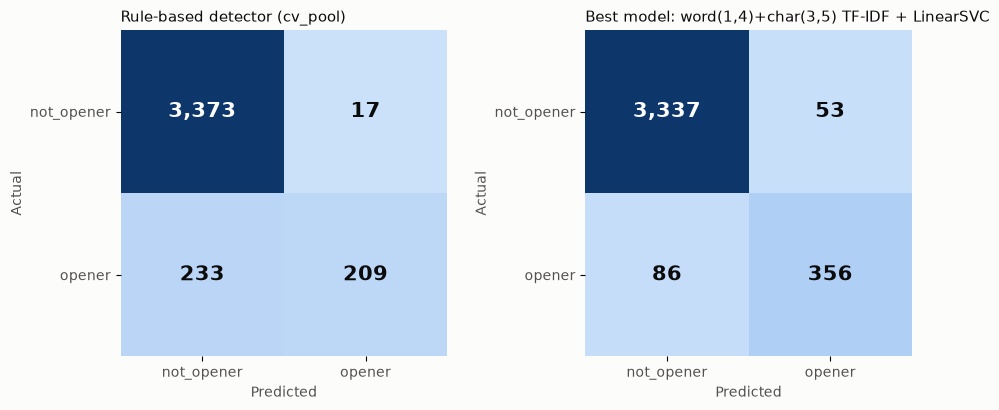

In [20]:
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, "../..")
from utils.colors import SEQ_BLUES, CHROME

ramp = [SEQ_BLUES[k] for k in sorted(SEQ_BLUES)]
seq_cmap = mcolors.LinearSegmentedColormap.from_list("seq_blues", ramp)

def plot_confusion_matrix(ax, actual, predicted, title):
    cm = np.array([
        [((actual == 0) & (predicted == 0)).sum(), ((actual == 0) & (predicted == 1)).sum()],
        [((actual == 1) & (predicted == 0)).sum(), ((actual == 1) & (predicted == 1)).sum()],
    ])
    ax.imshow(cm, cmap=seq_cmap, vmin=0)
    labels = ["not_opener", "opener"]
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, color=CHROME["ink_secondary"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, color=CHROME["ink_secondary"])
    ax.set_xlabel("Predicted", color=CHROME["ink_secondary"])
    ax.set_ylabel("Actual", color=CHROME["ink_secondary"])
    ax.set_title(title, color=CHROME["ink_primary"], fontsize=11, loc="left")
    cm_max = cm.max()
    for i in range(2):
        for j in range(2):
            text_color = CHROME["surface_light"] if cm[i, j] > cm_max * 0.5 else CHROME["ink_primary"]
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                     color=text_color, fontsize=15, fontweight="bold")
    for spine in ax.spines.values():
        spine.set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), facecolor=CHROME["surface_light"])
for ax in axes:
    ax.set_facecolor(CHROME["surface_light"])

cv_pool_actual = cv_pool["is_opener"].values
plot_confusion_matrix(axes[0], cv_pool_actual, cv_pool["rule_pred"].values,
                       "Rule-based detector (cv_pool)")
plot_confusion_matrix(axes[1], cv_pool_actual, cv_pool["pred"].values,
                       "Best model: word(1,4)+char(3,5) TF-IDF + LinearSVC")

plt.tight_layout()
plt.show()

## Miss rate by TOP document type

Restricted to true openers (`is_opener == 1`) in `cv_pool`, grouped by the
gold `type` field (only ever set on canonical opener rows, per
`top_boundaries_annotation_conventions.md` -- so this is undefined for true negatives/false
positives by construction). One series (a rate per category), so per the
dataviz skill's color-job rules this gets a single hue (`utils/colors.py`'s
`NAVY`), not a categorical palette -- and N is labeled alongside every bar
since several categories are small enough for the rate to be noisy on its own.

                        n  n_missed  miss_rate
type_group                                    
Gesetzentwurf          61         1   0.016393
Antrag                117         4   0.034188
Other                 107         8   0.074766
Dringlichkeitsantrag   13         3   0.230769
Abstimmung             13         4   0.307692
(blank)                47        21   0.446809
Anfrage                84        45   0.535714


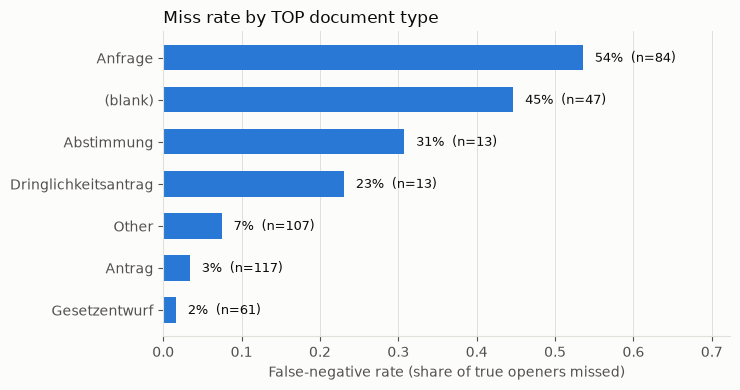

In [21]:
from utils.colors import NAVY

openers = cv_pool[cv_pool["is_opener"] == 1].copy()
openers["type_group"] = openers["type"].fillna("(blank)")
top_types = openers["type_group"].value_counts().head(6).index.tolist()
openers["type_group"] = openers["type_group"].where(openers["type_group"].isin(top_types), "Other")

type_summary = openers.groupby("type_group").agg(
    n=("is_opener", "size"), n_missed=("pred", lambda s: (s == 0).sum())
)
type_summary["miss_rate"] = type_summary["n_missed"] / type_summary["n"]
type_summary = type_summary.sort_values("miss_rate", ascending=True)
print(type_summary)

fig, ax = plt.subplots(figsize=(7.5, 4), facecolor=CHROME["surface_light"])
ax.set_facecolor(CHROME["surface_light"])

ax.barh(type_summary.index, type_summary["miss_rate"], color=NAVY, height=0.6)
for i, (rate, n) in enumerate(zip(type_summary["miss_rate"], type_summary["n"])):
    ax.text(rate + 0.015, i, f"{rate:.0%}  (n={n})", va="center",
            color=CHROME["ink_primary"], fontsize=9)

ax.set_xlim(0, type_summary["miss_rate"].max() * 1.35)
ax.set_xlabel("False-negative rate (share of true openers missed)", color=CHROME["ink_secondary"])
ax.set_title("Miss rate by TOP document type", loc="left", color=CHROME["ink_primary"], fontsize=12)
ax.tick_params(colors=CHROME["ink_secondary"])
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(CHROME["gridline"])
ax.xaxis.grid(True, color=CHROME["gridline"], linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Most meaningful predictors, on the winning model

Same fold-robustness logic as before (a single fit's top coefficients can
include fold-specific noise -- refit on each of the 5 training folds and count
how often a term lands in the top 15, rather than trusting one fit), now
applied to the actual final config (`word(1,4) + char(3,5)`, TF-IDF,
LinearSVC) instead of the earlier word(1,2)+LogReg exploration model. Word and
char features are reported separately (`FeatureUnion.get_feature_names_out()`
prefixes each with its block), since LinearSVC's linear `coef_` is directly
interpretable the same way LogReg's was.

In [22]:
from collections import Counter

TOP_N = 20
pos_folds, neg_folds = Counter(), Counter()
pos_coef_sum, neg_coef_sum = {}, {}

for train_idx, val_idx in sgkf.split(X, y, groups):
    vec = make_final_union()
    clf = LinearSVC(max_iter=10000, random_state=917)
    Xt = vec.fit_transform(X.iloc[train_idx])
    clf.fit(Xt, y.iloc[train_idx])
    coefs = clf.coef_[0]
    feature_names = vec.get_feature_names_out()

    order = np.argsort(coefs)
    for i in order[-TOP_N:]:
        term = feature_names[i]
        pos_folds[term] += 1
        pos_coef_sum[term] = pos_coef_sum.get(term, 0) + coefs[i]
    for i in order[:TOP_N]:
        term = feature_names[i]
        neg_folds[term] += 1
        neg_coef_sum[term] = neg_coef_sum.get(term, 0) + coefs[i]

print(f"Opener-predicting terms in the top {TOP_N} coefficients of >=1 of 5 folds:")
for term, n in sorted(pos_folds.items(), key=lambda kv: (-kv[1], -pos_coef_sum[kv[0]] / kv[1])):
    print(f"  {term!r:32s} {n}/5 folds, avg coef={pos_coef_sum[term] / n:.3f}")

print(f"\nNot-opener-predicting terms in the top {TOP_N} coefficients of >=1 of 5 folds:")
for term, n in sorted(neg_folds.items(), key=lambda kv: (-kv[1], kv[0])):
    print(f"  {term!r:32s} {n}/5 folds, avg coef={neg_coef_sum[term] / n:.3f}")

Opener-predicting terms in the top 20 coefficients of >=1 of 5 folds:
  'word_features__drs'             5/5 folds, avg coef=1.001
  'word_features__rufe'            5/5 folds, avg coef=0.923
  'word_features__ich rufe'        5/5 folds, avg coef=0.850
  'word_features__auf'             5/5 folds, avg coef=0.729
  'word_features__der'             5/5 folds, avg coef=0.699
  'char_features__ung'             5/5 folds, avg coef=0.594
  'word_features__des'             5/5 folds, avg coef=0.578
  'word_features__antrag der'      4/5 folds, avg coef=0.629
  'char_features__ 11'             4/5 folds, avg coef=0.626
  'word_features__anfrage'         4/5 folds, avg coef=0.541
  'word_features__zur frage'       3/5 folds, avg coef=0.621
  'word_features__eines'           3/5 folds, avg coef=0.604
  'word_features__kommen'          3/5 folds, avg coef=0.575
  'word_features__antrag'          3/5 folds, avg coef=0.563
  'word_features__drucksache'      3/5 folds, avg coef=0.561
  'word_feature

## Tried and rejected: elastic net regularization (properly nested, not guessed)

Motivation: word/char features are partially redundant (e.g. `lfd`/`lfd.`, see
earlier discussion) -- L1's "grouping effect" combined with L2 might handle
that more cleanly than pure L2, and might zero out truly uninformative
features for a sparser, more interpretable model. Tested on raw bag-of-words
counts (word(1,4)+char(3,5) union), not TF-IDF, matching the established
finding that raw counts beat TF-IDF for this task.

**Proper nested CV, not a fixed guess**: for each of the 5 outer folds, an
inner 3-fold grouped CV grid-searches `l1_ratio` in [0.1, 0.3, 0.5, 0.7, 0.9]
and regularization strength on that fold's *training* data only, then the
outer fold is scored with those selected hyperparameters -- the honest way to
report a tuned model's performance, since picking hyperparameters using the
same data you evaluate on inflates the score.

Two solvers tested, since `LinearSVC` doesn't support elastic net directly:

- `LogisticRegression(penalty="elasticnet", solver="saga")`: computationally
  infeasible at this scale -- one outer fold's grid search took roughly 40 min
  on saga's slow convergence over the combined word+char dimension; the full
  5-fold nested run would take hours. Its one completed fold's inner score was
  consistent with under-performing, not just untested.
- `SGDClassifier(loss="hinge", penalty="elasticnet")` (the actual elastic-net
  SVM): dramatically faster, so the full nested loop ran in under a minute.

**Result: F1 = 0.694 +/- 0.087 (mean P=0.628, R=0.806), ROC-AUC=0.903 +/-
0.049, PR-AUC=0.724 +/- 0.120, MCC=0.663 +/- 0.091** -- worse than the
established plain-L2 baselines on the identical features (counts+LogReg=0.783,
counts+LinearSVC=0.736) on F1, and worse on every other metric too against the
winning config (ROC-AUC=0.971, PR-AUC=0.881, MCC=0.800) -- not just a
threshold artifact, elastic net genuinely separates the classes less well
here. Also visibly unstable: one outer fold dropped to precision=0.433 with
recall=0.845 -- the tuned model there leans hard toward predicting "opener,"
not a consistently-slightly-worse fit.

**Conclusion: elastic net does not help here, tuned properly or not.**
Plain L2 stays the right choice for this feature representation and dataset
size -- an earlier untuned quick check (SGD elasticnet beating LinearSVC on
TF-IDF features) doesn't replicate once (a) hyperparameters are honestly
tuned within each fold rather than fixed at a single guessed value, and
(b) the feature representation is raw counts instead of TF-IDF.

In [23]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

def make_union_counts():
    return FeatureUnion([
        ("word_features", CountVectorizer(analyzer="word", ngram_range=(1, 4), min_df=2)),
        ("char_features", CountVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=5)),
    ])

elasticnet_param_grid = {
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    "clf__alpha": [0.0001, 0.001, 0.01, 0.1],
}

outer_p, outer_r, outer_f1, best_params_list = [], [], [], []
outer_roc_auc, outer_pr_auc, outer_mcc, outer_macro_f1 = [], [], [], []
for fold_i, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    Xtr, ytr, gtr = X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx]
    Xval, yval = X.iloc[val_idx], y.iloc[val_idx]
    inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=918)
    pipe = Pipeline([
        ("vec", make_union_counts()),
        ("clf", SGDClassifier(loss="hinge", penalty="elasticnet", max_iter=2000,
                               random_state=917, class_weight="balanced")),
    ])
    gs = GridSearchCV(pipe, elasticnet_param_grid, cv=list(inner_cv.split(Xtr, ytr, gtr)),
                       scoring="f1", n_jobs=-1)
    gs.fit(Xtr, ytr)
    preds = gs.predict(Xval)
    scores = get_scores(gs, Xval)
    p, r, f1, _ = precision_recall_fscore_support(yval, preds, average="binary", zero_division=0)
    outer_p.append(p); outer_r.append(r); outer_f1.append(f1); best_params_list.append(gs.best_params_)
    outer_macro_f1.append(f1_score(yval, preds, average="macro", zero_division=0))
    outer_roc_auc.append(roc_auc_score(yval, scores))
    outer_pr_auc.append(average_precision_score(yval, scores))
    outer_mcc.append(matthews_corrcoef(yval, preds))
    print(f"Fold {fold_i}: best_params={gs.best_params_} inner_f1={gs.best_score_:.3f}  "
          f"outer P={p:.3f} R={r:.3f} F1={f1:.3f}")

outer_f1 = np.array(outer_f1)
print(f"\nNested CV mean F1={outer_f1.mean():.3f} +/- {outer_f1.std(ddof=1):.3f}  "
      f"({outer_f1.mean() - RULE_F1_CV:+.3f} over rule-based detector)")
print(f"Mean precision={np.mean(outer_p):.3f}  Mean recall={np.mean(outer_r):.3f}")
print(f"Mean Macro-F1={np.mean(outer_macro_f1):.3f} +/- {np.std(outer_macro_f1, ddof=1):.3f}")
print(f"Mean ROC-AUC={np.mean(outer_roc_auc):.3f} +/- {np.std(outer_roc_auc, ddof=1):.3f}")
print(f"Mean PR-AUC={np.mean(outer_pr_auc):.3f} +/- {np.std(outer_pr_auc, ddof=1):.3f}")
print(f"Mean MCC={np.mean(outer_mcc):.3f} +/- {np.std(outer_mcc, ddof=1):.3f}")

Fold 0: best_params={'clf__alpha': 0.1, 'clf__l1_ratio': 0.1} inner_f1=0.653  outer P=0.474 R=0.890 F1=0.618


Fold 1: best_params={'clf__alpha': 0.01, 'clf__l1_ratio': 0.3} inner_f1=0.662  outer P=0.653 R=0.890 F1=0.753


Fold 2: best_params={'clf__alpha': 0.01, 'clf__l1_ratio': 0.3} inner_f1=0.673  outer P=0.717 R=0.835 F1=0.772


Fold 3: best_params={'clf__alpha': 0.01, 'clf__l1_ratio': 0.5} inner_f1=0.722  outer P=0.624 R=0.674 F1=0.648


Fold 4: best_params={'clf__alpha': 0.01, 'clf__l1_ratio': 0.3} inner_f1=0.732  outer P=0.800 R=0.627 F1=0.703

Nested CV mean F1=0.699 +/- 0.066  (+0.073 over rule-based detector)
Mean precision=0.654  Mean recall=0.783
Mean Macro-F1=0.826 +/- 0.041
Mean ROC-AUC=0.910 +/- 0.033
Mean PR-AUC=0.773 +/- 0.065
Mean MCC=0.667 +/- 0.070


## German BERT: does a pretrained transformer beat bag-of-words?

Motivation, from the error analysis above: `be`, `he`, `mv` fail because the
same underlying event ("announcing the next Fragestunde question") is phrased
three completely differently ways -- name+topic framing in `be`, numbered
framing in `he`, verb framing in `mv`. Bag-of-words needs a literal shared
n-gram to generalize across that, which is exactly why the Frage/Anfrage-number
canonicalization experiment above changed nothing. A pretrained language model
doesn't need surface-form overlap -- it can in principle recognize all three as
semantically similar events.

Two models, same BERT-base architecture: `deepset/gbert-base` (general-domain
baseline) and `chkla/parlbert-german-v2` (continued pretrained on GerParCor, a
parliamentary-protocol corpus -- domain-adapted).

Technical notes:
- Both repos' `config.json` predates the `model_type` key `AutoTokenizer`/
  `AutoModelForSequenceClassification` need, so both are loaded directly via
  `BertTokenizerFast`/`BertForSequenceClassification`, bypassing Auto* inference.
- Neither checkpoint includes pooler weights (`bert.pooler.dense`) or a
  classification head -- both start those parts from the same fresh random
  initialization, so any performance gap is attributable to the pretrained
  encoder weights only, not an unequal head.
- Same 5-fold grouped CV (`sgkf`/`X`/`y`/`groups`) as every classical model
  above, for a direct comparison; class-weighted cross-entropy loss, the same
  idea as `class_weight="balanced"` elsewhere, since the imbalance is ~90/10.
- **Truncation length, checked empirically, not assumed**: content length is
  heavily right-skewed (median 23 tokens, 75th pct 47, but 90th pct jumps to
  195). `max_length=128` truncates only 13% of contributions -- and only their
  tail. Since the FP error analysis found the misleading "TOP mentioned in
  passing" text tends to sit deep inside a long joined block while a genuine
  opener's trigger phrase sits at the start, truncating the tail should if
  anything help the long-block false-positive problem, not hurt it.
- 2 epochs, batch size 16, `lr=2e-5` -- standard BERT fine-tuning defaults.
  Originally tried 3 epochs at `max_length=256`, but a first attempt at that
  setting blew past a 1-hour timeout without finishing even one model: a
  first speed probe (reusing one fixed short sentence for every timed step)
  badly underestimated the real per-step cost, since real batches often
  actually reach the 256-token cap, unlike that probe's short, uniform input.
  Timed against real, length-varied text before committing to these settings.
- Runs on `mps` (Apple GPU); roughly 15-20 minutes total for both models
  across all 5 folds at these settings.

In [24]:
import torch
import torch.nn.functional as F
from transformers import BertTokenizerFast, BertForSequenceClassification

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {device}")


def run_bert_cv(model_name, epochs=2, batch_size=16, max_length=128, lr=2e-5):
    torch.manual_seed(917)
    np.random.seed(917)
    fold_p, fold_r, fold_f1, fold_macro_f1 = [], [], [], []
    fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []

    for train_idx, val_idx in sgkf.split(X, y, groups):
        tok = BertTokenizerFast.from_pretrained(model_name)
        model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

        Xtr, ytr = X.iloc[train_idx].tolist(), y.iloc[train_idx].tolist()
        Xval, yval = X.iloc[val_idx].tolist(), y.iloc[val_idx].to_numpy()

        class_counts = np.bincount(ytr)
        class_weights = torch.tensor(len(ytr) / (2.0 * class_counts), dtype=torch.float32).to(device)

        opt = torch.optim.AdamW(model.parameters(), lr=lr)
        model.train()
        for _ in range(epochs):
            perm = np.random.permutation(len(Xtr))
            for i in range(0, len(perm), batch_size):
                idx = perm[i:i + batch_size]
                texts = [Xtr[j] for j in idx]
                labels = torch.tensor([ytr[j] for j in idx], dtype=torch.long).to(device)
                batch = tok(texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
                opt.zero_grad()
                loss = F.cross_entropy(model(**batch).logits, labels, weight=class_weights)
                loss.backward()
                opt.step()

        model.eval()
        probs = []
        with torch.no_grad():
            for i in range(0, len(Xval), batch_size):
                texts = Xval[i:i + batch_size]
                batch = tok(texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
                probs.extend(F.softmax(model(**batch).logits, dim=-1)[:, 1].cpu().numpy().tolist())
        probs = np.array(probs)
        preds = (probs >= 0.5).astype(int)

        p, r, f1, _ = precision_recall_fscore_support(yval, preds, average="binary", zero_division=0)
        fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
        fold_macro_f1.append(f1_score(yval, preds, average="macro", zero_division=0))
        fold_roc_auc.append(roc_auc_score(yval, probs))
        fold_pr_auc.append(average_precision_score(yval, probs))
        fold_mcc.append(matthews_corrcoef(yval, preds))

        del model, tok
        if device.type == "mps":
            torch.mps.empty_cache()

    fold_f1 = np.array(fold_f1)
    print(f"{model_name:28s} F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
          f"Macro-F1={np.mean(fold_macro_f1):.3f} "
          f"P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f} "
          f"ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
          f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)")
    return fold_f1.mean()

device: mps


In [25]:
bert_models = ["deepset/gbert-base", "chkla/parlbert-german-v2"]
bert_results = {name: run_bert_cv(name) for name in bert_models}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: deepset/gbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: deepset/gbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: chkla/parlbert-german-v2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params 

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: chkla/parlbert-german-v2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params 

chkla/parlbert-german-v2     F1=0.750 +/- 0.056 Macro-F1=0.855 P=0.672 R=0.873 ROC-AUC=0.977 PR-AUC=0.865 MCC=0.726  (+0.124 F1 over rule-based detector)
